# Results and Data Analysis for Movie Recommender

This notebook provides visualizations for the Project Report's **Results and Discussion** section. 
It includes exploratory data analysis (EDA) of the input datasets and graphs depicting the evaluation metrics of our recommendation system.

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
from data_loader import load_movies, load_ratings
from evaluation import compute_metrics

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Dataset Overview

In [37]:
# Load data using the backend's data_loader
movies_df = load_movies()
ratings_df = load_ratings()

print(f"Total Movies: {len(movies_df):,}")
print(f"Total Ratings: {len(ratings_df):,}")

Total Movies: 10,329
Total Ratings: 105,339


## 2. Distribution of Ratings
Visualizing how users rate movies. Are people generally generous or strict with their ratings?

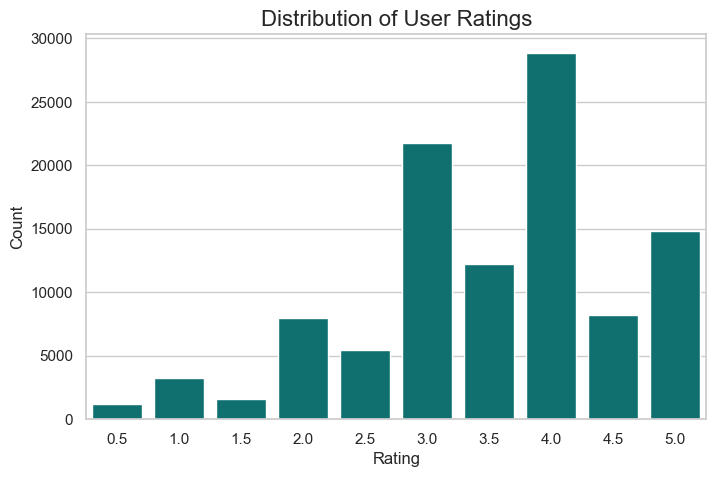

In [38]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='rating', data=ratings_df, color='teal')
plt.title('Distribution of User Ratings', fontsize=16)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()
ax.figure.savefig("rating_distribution.png", dpi=300)

## 3. Top Genres in the Dataset

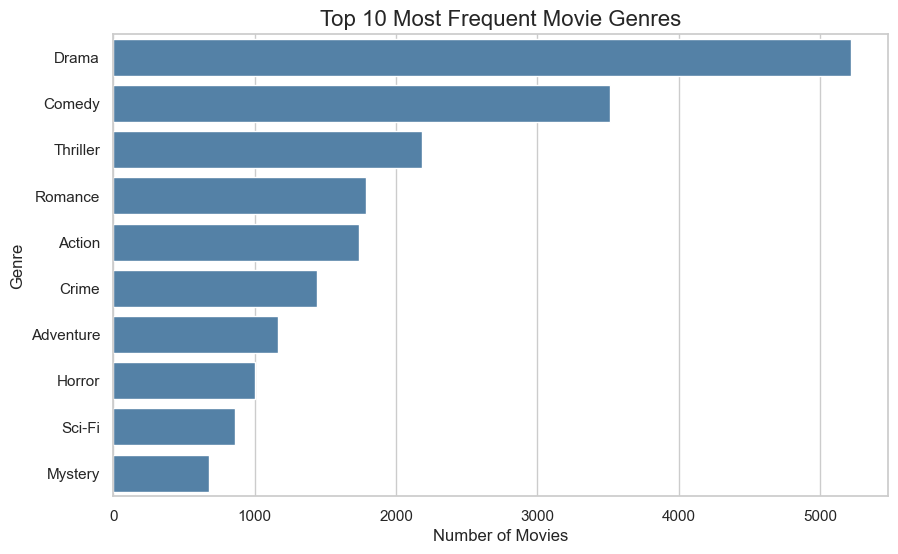

In [39]:
# Split the genres string into individual genres, then explode into separate rows
genres_exploded = movies_df['genres'].str.split('|').explode()
genre_counts = genres_exploded.value_counts().head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=genre_counts.values, y=genre_counts.index, color='steelblue')
plt.title('Top 10 Most Frequent Movie Genres', fontsize=16)
plt.xlabel('Number of Movies', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.show()
ax.figure.savefig("top_genres.png", dpi=300)

## 4. Deeper EDA: User Behavior and Catalog Popularity
To strengthen the final report narrative, this section studies user activity levels and movie popularity distribution. These patterns explain sparse feedback and long-tail behavior in recommendation tasks.

User activity summary:
count     668.00
mean      157.69
std       319.71
min        20.00
25%        35.00
50%        70.50
75%       153.00
max      5678.00
dtype: float64


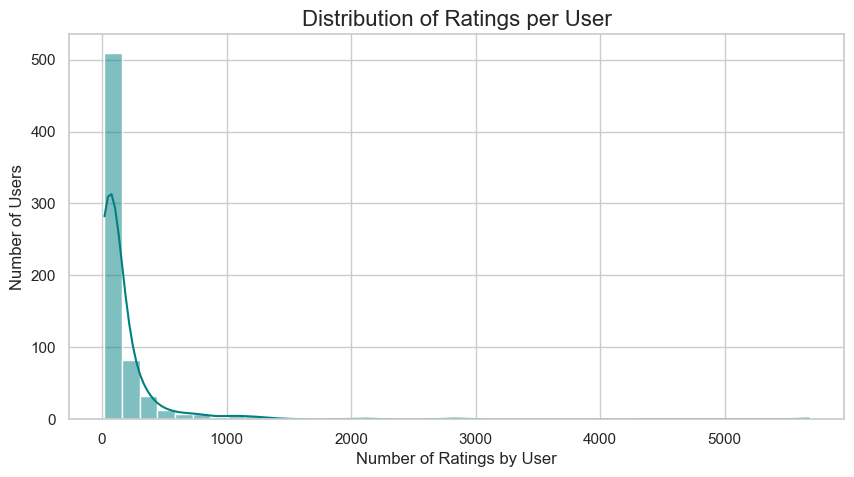

In [40]:
# Ratings per user: activity distribution
ratings_per_user = ratings_df.groupby('userId').size()

print('User activity summary:')
print(ratings_per_user.describe().round(2))

plt.figure(figsize=(10, 5))
ax = sns.histplot(ratings_per_user, bins=40, kde=True, color='teal')
plt.title('Distribution of Ratings per User', fontsize=16)
plt.xlabel('Number of Ratings by User', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.show()
ax.figure.savefig('ratings_per_user_distribution.png', dpi=300)

Interpretation: The histogram shows a right-skewed user activity pattern. Most users contribute only a small number of ratings, while a smaller group is highly active. This sparsity motivates hybrid recommendation strategies because user profiles are uneven in depth.

Movie popularity summary:
count    10325.00
mean        10.20
std         22.83
min          1.00
25%          1.00
50%          3.00
75%          8.00
max        325.00
dtype: float64


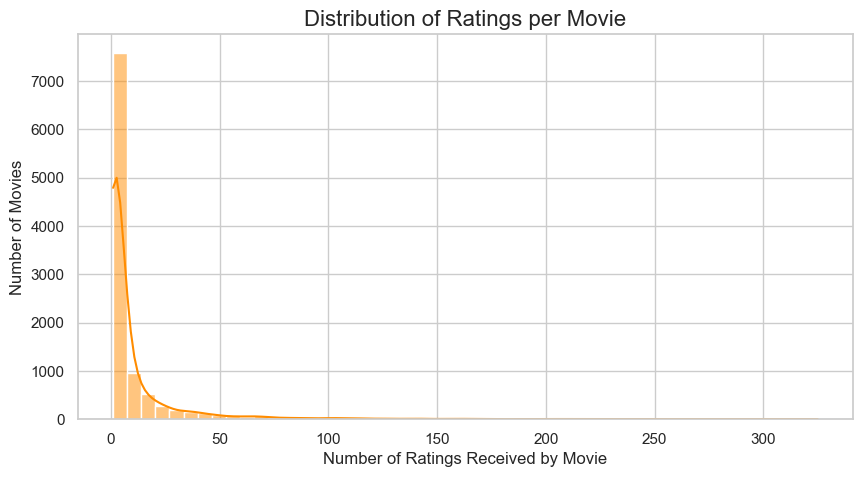

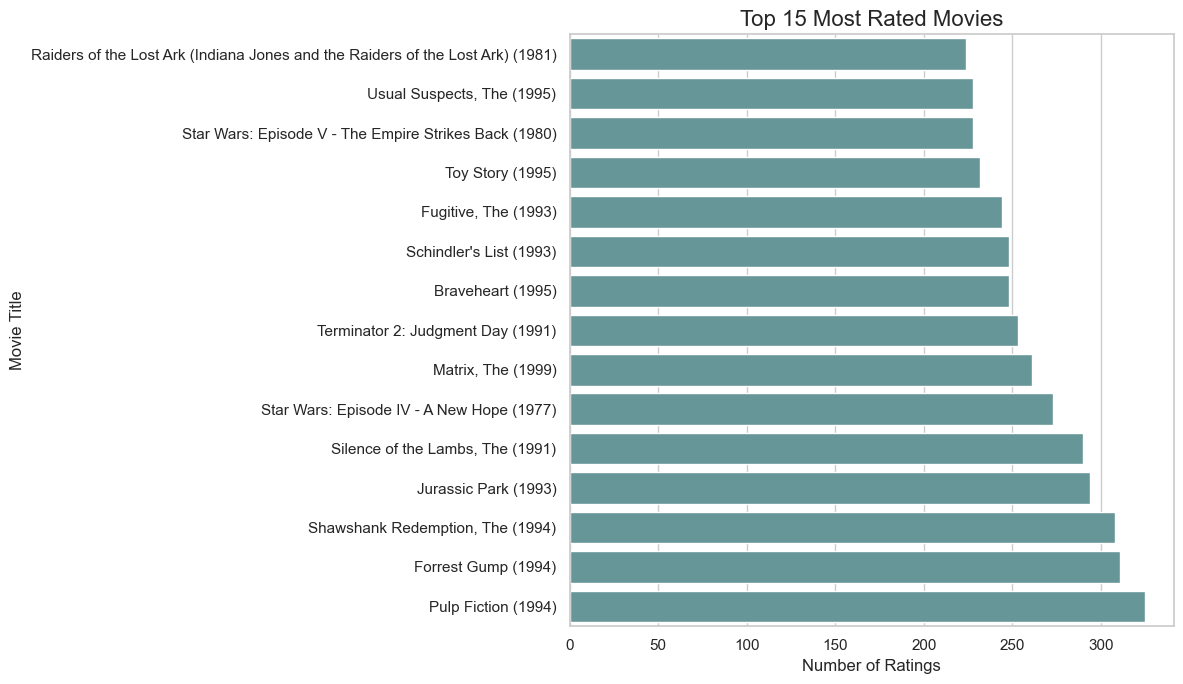

In [41]:
# Ratings per movie: popularity long-tail
ratings_per_movie = ratings_df.groupby('movieId').size().sort_values(ascending=False)

print('Movie popularity summary:')
print(ratings_per_movie.describe().round(2))

plt.figure(figsize=(10, 5))
ax = sns.histplot(ratings_per_movie, bins=50, kde=True, color='darkorange')
plt.title('Distribution of Ratings per Movie', fontsize=16)
plt.xlabel('Number of Ratings Received by Movie', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.show()
ax.figure.savefig('ratings_per_movie_distribution.png', dpi=300)

# Top most-rated movies for interpretability
popular_movie_ids = ratings_per_movie.head(15).index
popular_movies = movies_df[movies_df['movieId'].isin(popular_movie_ids)].copy()
popular_movies['rating_count'] = popular_movies['movieId'].map(ratings_per_movie)
popular_movies = popular_movies.sort_values('rating_count', ascending=True)

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=popular_movies, x='rating_count', y='title', color='cadetblue')
plt.title('Top 15 Most Rated Movies', fontsize=16)
plt.xlabel('Number of Ratings', fontsize=12)
plt.ylabel('Movie Title', fontsize=12)
plt.tight_layout()
plt.show()
ax.figure.savefig('top_rated_movies_count.png', dpi=300)

Interpretation: Movie popularity follows a long-tail structure. A limited set of titles receives many interactions, while most movies receive relatively few ratings. The top-15 chart highlights head items that dominate engagement and can bias naive recommenders toward already-popular content.

## 5. Feature Engineering for Richer Insights
In this section, we create additional columns to enrich analysis: release year, decade, average movie rating, rating count, and a weighted score that balances quality and popularity.

In [42]:
# Build enriched movie table with additional analytical columns
movies_enriched = movies_df.copy()

# Extract year from title format like "Movie Name (1995)"
movies_enriched['release_year'] = pd.to_numeric(
    movies_enriched['title'].str.extract(r'\((\d{4})\)')[0],
    errors='coerce'
)
movies_enriched['decade'] = (movies_enriched['release_year'] // 10 * 10).astype('Int64')

movie_stats = (
    ratings_df.groupby('movieId')['rating']
    .agg(avg_rating='mean', rating_count='count')
    .reset_index()
)

movies_enriched = movies_enriched.merge(movie_stats, on='movieId', how='left')

# Weighted score: shrinks low-count movies toward global mean
C = ratings_df['rating'].mean()
m = movies_enriched['rating_count'].quantile(0.75)
movies_enriched['weighted_score'] = (
    (movies_enriched['rating_count'] / (movies_enriched['rating_count'] + m)) * movies_enriched['avg_rating']
    + (m / (movies_enriched['rating_count'] + m)) * C
)

print('New columns added: release_year, decade, avg_rating, rating_count, weighted_score')
print(movies_enriched[['title', 'release_year', 'decade', 'avg_rating', 'rating_count', 'weighted_score']].head())

New columns added: release_year, decade, avg_rating, rating_count, weighted_score
                                title  release_year  decade  avg_rating  \
0                    Toy Story (1995)        1995.0    1990    3.907328   
1                      Jumanji (1995)        1995.0    1990    3.353261   
2             Grumpier Old Men (1995)        1995.0    1990    3.189655   
3            Waiting to Exhale (1995)        1995.0    1990    2.818182   
4  Father of the Bride Part II (1995)        1995.0    1990    3.250000   

   rating_count  weighted_score  
0         232.0        3.894312  
1          92.0        3.366348  
2          58.0        3.229315  
3          11.0        3.112358  
4          62.0        3.280497  


Interpretation: The scatter plot suggests that higher engagement does not automatically imply higher quality, although very low-support items are more volatile. The log-scaled x-axis makes the tail visible and shows why confidence-aware ranking (for example, weighted score) is useful.

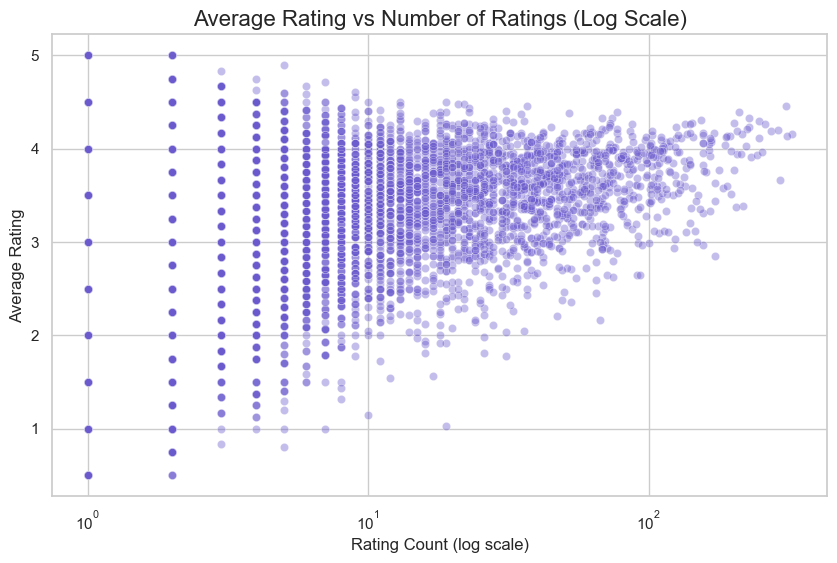

In [43]:
# Relationship between popularity (rating_count) and quality (avg_rating)
plot_df = movies_enriched.dropna(subset=['rating_count', 'avg_rating']).copy()

plt.figure(figsize=(10, 6))
ax = sns.scatterplot(
    data=plot_df,
    x='rating_count',
    y='avg_rating',
    alpha=0.4,
    s=35,
    color='slateblue'
)
plt.xscale('log')
plt.title('Average Rating vs Number of Ratings (Log Scale)', fontsize=16)
plt.xlabel('Rating Count (log scale)', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.show()
ax.figure.savefig('rating_quality_vs_popularity.png', dpi=300)

## 6. Temporal and Genre Stories
We now inspect time-based behavior and genre-level quality trends to provide stronger storytelling for the final project submission.

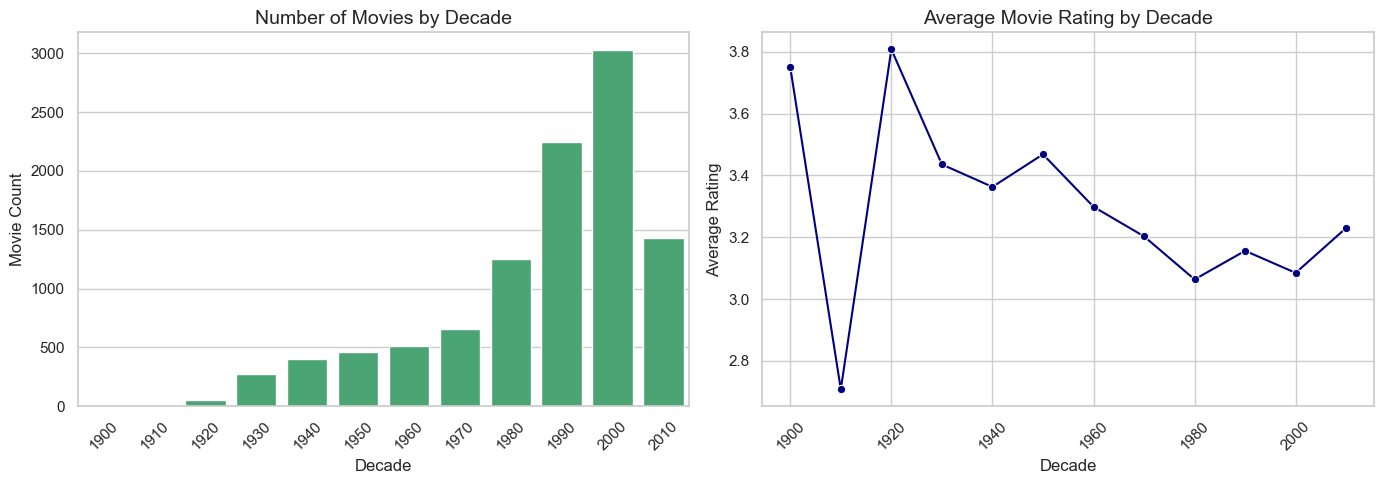

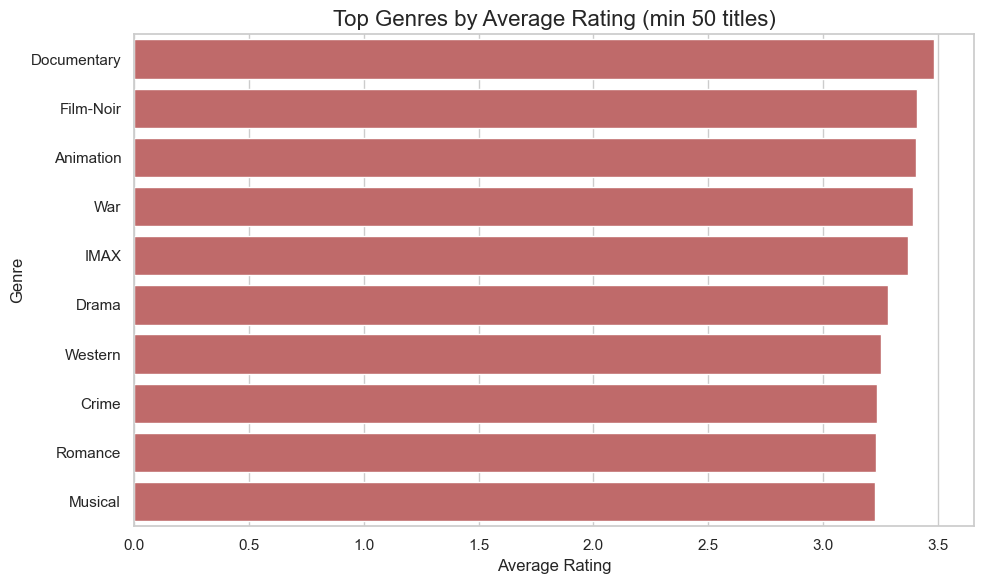

In [44]:
# Decade-wise catalog size and average rating trend
decade_summary = (
    movies_enriched.dropna(subset=['decade'])
    .groupby('decade')
    .agg(movie_count=('movieId', 'count'), mean_rating=('avg_rating', 'mean'))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=decade_summary, x='decade', y='movie_count', color='mediumseagreen', ax=axes[0])
axes[0].set_title('Number of Movies by Decade', fontsize=14)
axes[0].set_xlabel('Decade')
axes[0].set_ylabel('Movie Count')
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(data=decade_summary, x='decade', y='mean_rating', marker='o', color='navy', ax=axes[1])
axes[1].set_title('Average Movie Rating by Decade', fontsize=14)
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('Average Rating')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
fig.savefig('decade_summary.png', dpi=300)

# Genre quality ranking (with minimum support to avoid noisy low-count titles)
genre_quality = (
    movies_enriched.dropna(subset=['avg_rating', 'rating_count'])
    .assign(genres=movies_enriched['genres'].str.split('|'))
    .explode('genres')
)

genre_quality = genre_quality.groupby('genres').agg(
    avg_genre_rating=('avg_rating', 'mean'),
    avg_genre_votes=('rating_count', 'mean'),
    title_count=('movieId', 'count')
).reset_index()

genre_quality = genre_quality[genre_quality['title_count'] >= 50]

genre_top = genre_quality.sort_values('avg_genre_rating', ascending=False).head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=genre_top, x='avg_genre_rating', y='genres', color='indianred')
plt.title('Top Genres by Average Rating (min 50 titles)', fontsize=16)
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.tight_layout()
plt.show()
ax.figure.savefig('top_genres_by_rating.png', dpi=300)

Interpretation: Decade-level trends summarize catalog evolution and audience response over time. Genre-level averages (with support filtering) surface consistently strong categories while reducing noise from underrepresented genres.

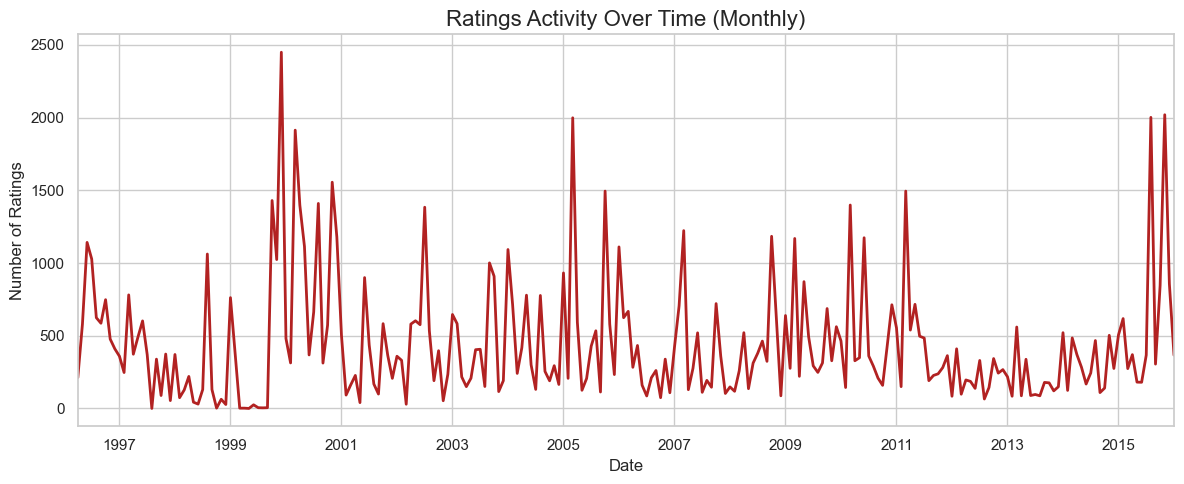

In [45]:
# Time trend in rating activity (if timestamp is available)
if 'timestamp' in ratings_df.columns:
    ratings_time = ratings_df.copy()
    ratings_time['rating_date'] = pd.to_datetime(ratings_time['timestamp'], unit='s', errors='coerce')
    ratings_time = ratings_time.dropna(subset=['rating_date'])
    monthly_trend = ratings_time.set_index('rating_date').resample('ME').size()

    plt.figure(figsize=(12, 5))
    ax = monthly_trend.plot(color='firebrick', linewidth=2)
    plt.title('Ratings Activity Over Time (Monthly)', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Number of Ratings', fontsize=12)
    plt.tight_layout()
    plt.show()
    ax.figure.savefig('ratings_monthly_trend.png', dpi=300)
else:
    print("No 'timestamp' column found. Skipping temporal trend plot.")

Interpretation: Temporal activity highlights growth and/or seasonality in user interactions when timestamp data is available. These patterns can inform time-aware evaluation splits and future modeling choices (for example, recency-sensitive recommendations).

## 7. Model Evaluation Metrics
We compute the RMSE, MAE, Precision@10, and Recall@10 from our `evaluation.py` module. 
*Note: This might take a few seconds as it calculates SVD across the dataset matrix.*

In [46]:
print("Computing Hybrid Model Metrics... (This may take a moment)")
metrics = compute_metrics(k=10)

print("---- Final Metrics ----")
for k, v in metrics.items():
    print(f"{k.upper()}: {v}")

Computing Hybrid Model Metrics... (This may take a moment)
---- Final Metrics ----
RMSE: 3.2217
MAE: 3.0159
PRECISION_AT_10: 0.1917
RECALL_AT_10: 0.1968


### Visualizing the Error Metrics (RMSE & MAE)

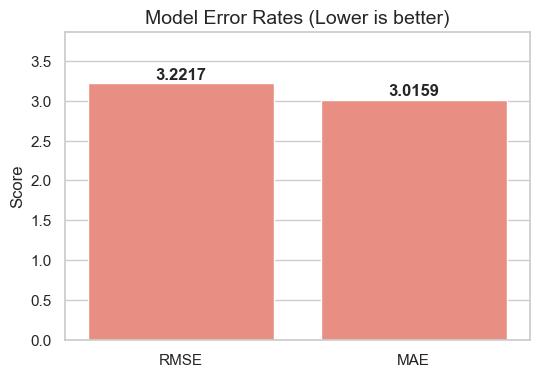

In [47]:
error_metrics = {'RMSE': metrics['rmse'], 'MAE': metrics['mae']}

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=list(error_metrics.keys()), y=list(error_metrics.values()), color='salmon')
plt.title('Model Error Rates (Lower is better)', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, max(error_metrics.values()) * 1.2)
for i, v in enumerate(error_metrics.values()):
    ax.text(i, v + 0.05, str(round(v, 4)), ha='center', fontweight='bold')
plt.show()
ax.figure.savefig("error_metrics.png", dpi=300)

### Visualizing Retrieval Accuracy (Precision & Recall @ 10)

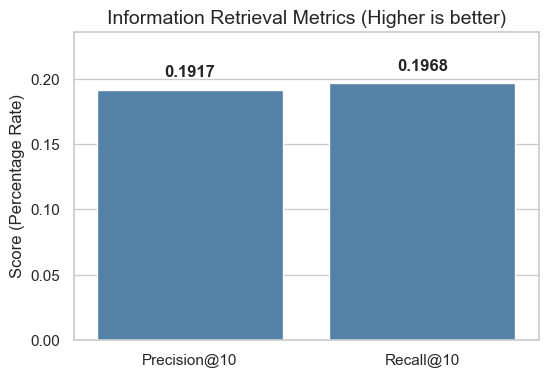

In [48]:
retrieval_metrics = {'Precision@10': metrics['precision_at_10'], 'Recall@10': metrics['recall_at_10']}

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=list(retrieval_metrics.keys()), y=list(retrieval_metrics.values()), color='steelblue')
plt.title('Information Retrieval Metrics (Higher is better)', fontsize=14)
plt.ylabel('Score (Percentage Rate)', fontsize=12)
plt.ylim(0, max(retrieval_metrics.values()) * 1.2)
for i, v in enumerate(retrieval_metrics.values()):
    ax.text(i, v + 0.01, str(round(v, 4)), ha='center', fontweight='bold')
plt.show()
ax.figure.savefig("retrieval_metrics.png", dpi=300)

In [49]:
# Compact key findings table for report readability
movie_count = len(movies_df)
rating_count = len(ratings_df)
user_count = ratings_df['userId'].nunique()
mean_rating = ratings_df['rating'].mean()

key_findings = [
    ('Total movies', f"{movie_count:,}"),
    ('Total ratings', f"{rating_count:,}"),
    ('Total users', f"{user_count:,}"),
    ('Average user rating', f"{mean_rating:.3f}"),
    ('Median ratings per user', f"{ratings_per_user.median():.1f}"),
    ('Median ratings per movie', f"{ratings_per_movie.median():.1f}"),
    ('Most common genre', str(genres_exploded.value_counts().index[0])),
    ('Top weighted movie', str(movies_enriched.sort_values('weighted_score', ascending=False).iloc[0]['title'])),
]

if 'metrics' in globals():
    key_findings.extend([
        ('RMSE', f"{metrics['rmse']:.4f}"),
        ('MAE', f"{metrics['mae']:.4f}"),
        ('Precision@10', f"{metrics['precision_at_10']:.4f}"),
        ('Recall@10', f"{metrics['recall_at_10']:.4f}"),
    ])

summary_df = pd.DataFrame(key_findings, columns=['Metric', 'Value'])
summary_df

,Metric,Value
0,Total movies,"10,329"
1,Total ratings,"105,339"
2,Total users,668
3,Average user rating,3.517
4,Median ratings per user,70.5
5,Median ratings per movie,3.0
6,Most common genre,Drama
7,Top weighted movie,"Shawshank Redemption, The (1994)"
8,RMSE,3.2217
9,MAE,3.0159


## 8. Key Findings Summary
The table above consolidates major EDA and evaluation observations into a compact form for final project reporting.